# Project 2: Machine Learning Classification with Scikit-Learn

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## Load Iris Dataset

In [2]:

iris=load_iris()
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df["species"]=iris.target_names[iris.target]

print("Dataset shape:",df.shape)
print("Species:",df["species"].unique())
df.head()


Dataset shape: (150, 5)
Species: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Prepare Features and Labels

In [3]:

X=iris.data
y=iris.target

print("Features shape:",X.shape)
print("Labels shape:",y.shape)
print("Unique classes:",set(y))


Features shape: (150, 4)
Labels shape: (150,)
Unique classes: {np.int64(0), np.int64(1), np.int64(2)}


## Split Data

In [4]:

X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:",X_train.shape[0])
print("Testing samples:",X_test.shape[0])
print(dict(zip(*np.unique(y_train,return_counts=True))))


Training samples: 120
Testing samples: 30
{np.int64(0): np.int64(40), np.int64(1): np.int64(40), np.int64(2): np.int64(40)}


## Decision Tree

In [5]:

dt_model=DecisionTreeClassifier(max_depth=3,random_state=42)
dt_model.fit(X_train,y_train)

print("Model training complete!")
print("Leaves:",dt_model.get_n_leaves())
print("Depth:",dt_model.get_depth())


Model training complete!
Leaves: 5
Depth: 3


## Predictions

In [6]:

y_pred=dt_model.predict(X_test)

print("Actual:",y_test[:10])
print("Predicted:",y_pred[:10])

new_flower=[[5.1,3.5,1.4,0.2]]
prediction=dt_model.predict(new_flower)
prediction_proba=dt_model.predict_proba(new_flower)

print("Predicted species:",iris.target_names[prediction[0]])
print("Confidence:",prediction_proba)


Actual: [0 2 1 1 0 1 0 0 2 1]
Predicted: [0 2 1 1 0 1 0 0 2 1]
Predicted species: setosa
Confidence: [[1. 0. 0.]]


## Evaluation

Accuracy: 0.9666666666666667
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



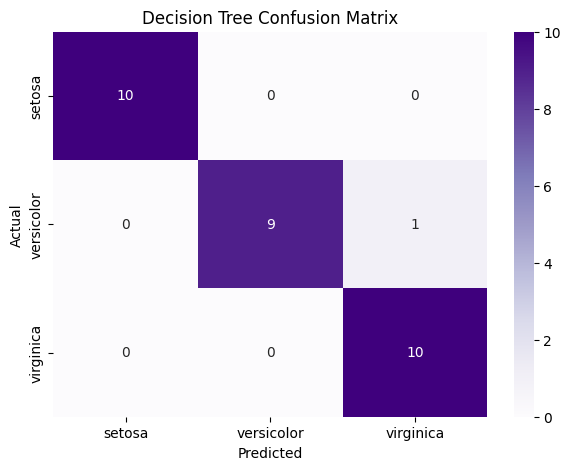

In [7]:

accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

print(classification_report(y_test,y_pred,target_names=iris.target_names))

cm=confusion_matrix(y_test,y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Purples",
xticklabels=iris.target_names,
yticklabels=iris.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.savefig("confusion_matrix_dt.png")
plt.show()


## Decision Tree Visualization

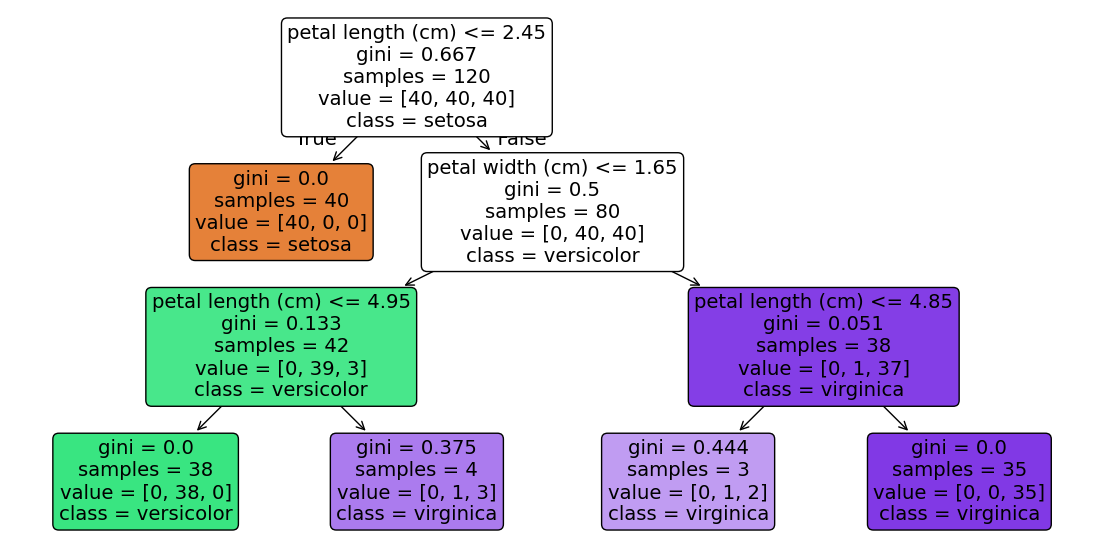

In [8]:

plt.figure(figsize=(14,7))
plot_tree(
    dt_model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True
)
plt.savefig("decision_tree_visual.png",bbox_inches="tight")
plt.show()


## Experiment with Tree Depth

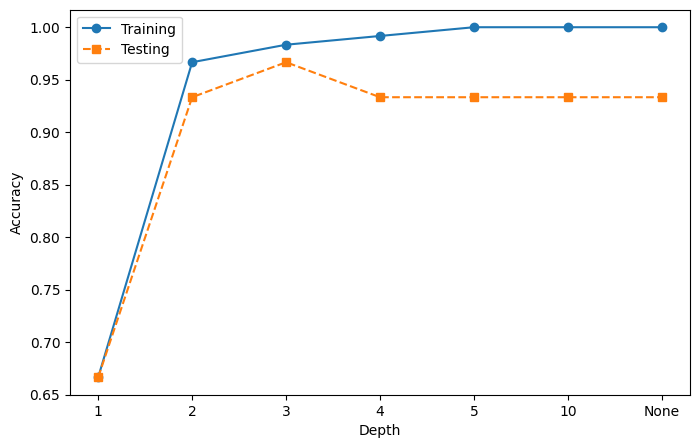

In [9]:

depths=[1,2,3,4,5,10,None]
train_acc=[]
test_acc=[]

for depth in depths:
    model=DecisionTreeClassifier(max_depth=depth,random_state=42)
    model.fit(X_train,y_train)
    train_acc.append(model.score(X_train,y_train))
    test_acc.append(model.score(X_test,y_test))

plt.figure(figsize=(8,5))
plt.plot([str(d) for d in depths],train_acc,"o-",label="Training")
plt.plot([str(d) for d in depths],test_acc,"s--",label="Testing")
plt.legend()
plt.xlabel("Depth")
plt.ylabel("Accuracy")
plt.savefig("depth_vs_accuracy.png")
plt.show()


## Random Forest

In [10]:

rf_model=RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train,y_train)
y_pred_rf=rf_model.predict(X_test)
print("Random Forest Accuracy:",accuracy_score(y_test,y_pred_rf))


Random Forest Accuracy: 0.9333333333333333


## Cross Validation

In [11]:

dt_cv=cross_val_score(
DecisionTreeClassifier(max_depth=3,random_state=42),
X,y,cv=5,scoring="accuracy")

rf_cv=cross_val_score(
RandomForestClassifier(n_estimators=100,random_state=42),
X,y,cv=5,scoring="accuracy")

print(dt_cv)
print(dt_cv.mean(),dt_cv.std())
print(rf_cv)
print(rf_cv.mean(),rf_cv.std())


[0.96666667 0.96666667 0.93333333 1.         1.        ]
0.9733333333333334 0.02494438257849294
[0.96666667 0.96666667 0.93333333 0.96666667 1.        ]
0.9666666666666668 0.02108185106778919


## Feature Importance

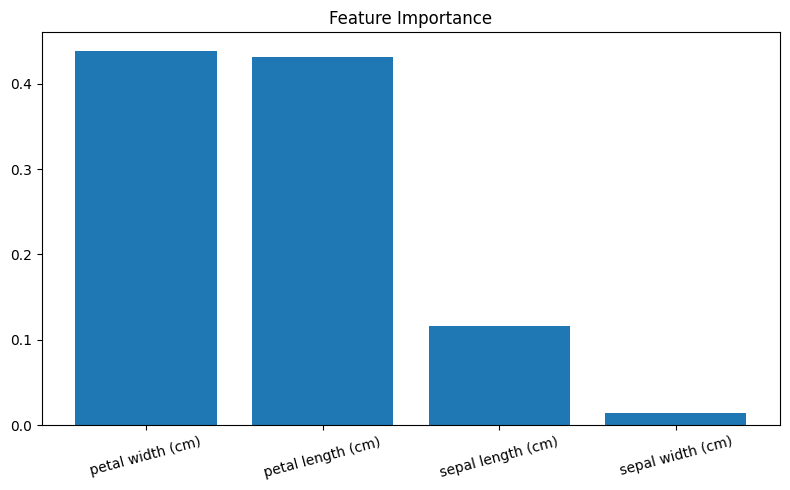

In [12]:

imp=rf_model.feature_importances_
idx=np.argsort(imp)[::-1]

plt.figure(figsize=(8,5))
plt.bar(range(4),imp[idx])
plt.xticks(range(4),[iris.feature_names[i] for i in idx],rotation=15)
plt.title("Feature Importance")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()


## Model Comparison

Decision Tree 0.9733333333333334 0.02494438257849294
Random Forest 0.9666666666666668 0.02108185106778919
Gradient Boosting 0.9600000000000002 0.03265986323710903
KNN 0.9733333333333334 0.02494438257849294
Logistic Regression 0.9733333333333334 0.02494438257849294


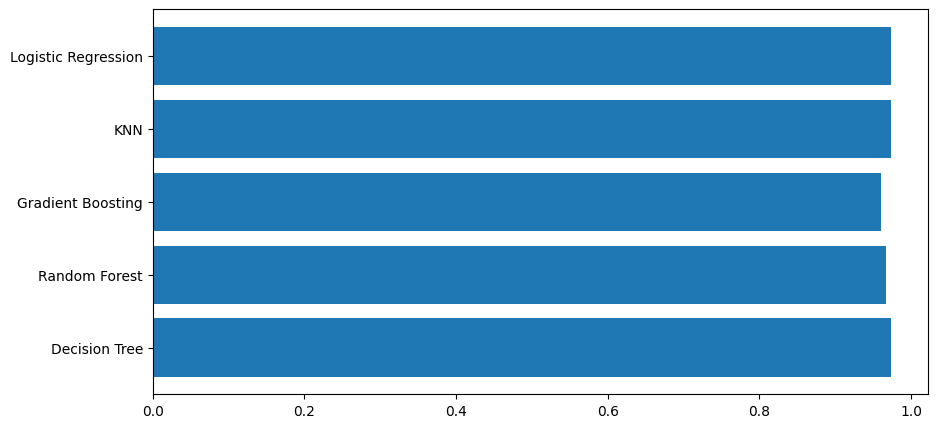

In [13]:

models={
"Decision Tree":DecisionTreeClassifier(max_depth=3,random_state=42),
"Random Forest":RandomForestClassifier(random_state=42),
"Gradient Boosting":GradientBoostingClassifier(random_state=42),
"KNN":KNeighborsClassifier(),
"Logistic Regression":LogisticRegression(max_iter=200)
}

results={}
for name,model in models.items():
    scores=cross_val_score(model,X,y,cv=5,scoring="accuracy")
    results[name]=scores
    print(name,scores.mean(),scores.std())

plt.figure(figsize=(10,5))
plt.barh(list(results.keys()),[v.mean() for v in results.values()])
plt.savefig("model_comparison.png")
plt.show()


## GridSearchCV

In [14]:

param_grid={
"n_estimators":[50,100,200],
"max_depth":[3,5,10,None],
"min_samples_split":[2,5,10]
}

grid=GridSearchCV(
RandomForestClassifier(random_state=42),
param_grid,
cv=5,
scoring="accuracy",
n_jobs=-1
)

grid.fit(X_train,y_train)

print("Best Parameters:",grid.best_params_)
print("Best CV Accuracy:",grid.best_score_)

best_model=grid.best_estimator_
print("Final Test Accuracy:",best_model.score(X_test,y_test))


Best Parameters: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 50}
Best CV Accuracy: 0.9583333333333334
Final Test Accuracy: 0.9666666666666667


## Final Evaluation Report

FINAL MODEL EVALUATION REPORT
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



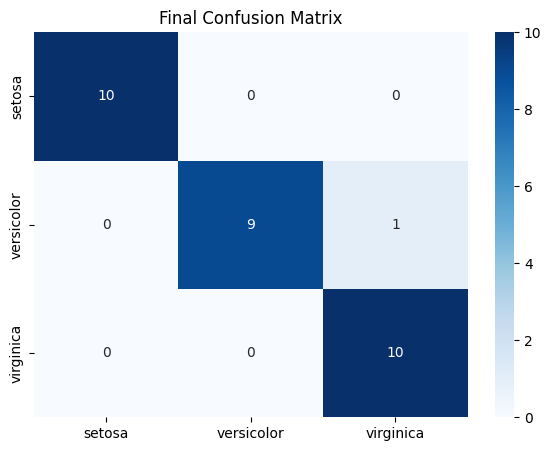

In [15]:

y_final_pred=best_model.predict(X_test)

print("="*60)
print("FINAL MODEL EVALUATION REPORT")
print("="*60)
print(classification_report(y_test,y_final_pred,target_names=iris.target_names))

cm=confusion_matrix(y_test,y_final_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
xticklabels=iris.target_names,
yticklabels=iris.target_names)
plt.title("Final Confusion Matrix")
plt.show()
